## Script to generate figure 4


In [418]:

import numpy as np
import pandas as pd
import matplotlib 
from scipy import stats
import matplotlib.pyplot as plt
from itertools import product
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
mpl.rcParams['svg.fonttype'] = 'none'
cm = 1/2.54  # centimeters in inches
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [ ]:
transparent = True
df = pd.read_csv('../data_test_Uni_1_no_S.csv')
#df2 = pd.read_csv('../data_final_push.csv')
#fuse the two dataframes
#df = pd.concat([df, df2], ignore_index=True)

axis_fontsize = 7

param_list = ["S","E",'D',"N"]
pd.set_option('display.max_columns', None)

df["DeltaGoal"] = df["maxed_goal_value"] - df["goal_base"]
df["delta_opti_goal"] = df["optimal_goal_value"] - df["goal_base"]
df["DeltaCorr"] = df['correlation_on_max_proxy'] -  df['correlation_base'] 
df["DeltaProx"] = df["maxed_proxy_value"] - df["proxy_base"]
df["D"] = df['goal_discard'] - df["proxy_discard"]
df['E'] = df["avg_number_of_edges"]
df['S'] = df["alpha"]
df['SpectralRadius'] = df['spectral_radius'] 
df['N'] = df["n"]
df['proxy_failure'] = df["DeltaCorr"] < 0
df['strong'] = (df["DeltaCorr"] < 0) & (df["DeltaGoal"] <= 0)
df['weak'] = (df["DeltaCorr"] < 0) & (df["DeltaGoal"] > 0) & (df["DeltaProx"] > df["DeltaGoal"])
df['benign'] = (df["DeltaCorr"] < 0) & (df["DeltaProx"] <= df["DeltaGoal"])

sub_df = df[df["DeltaCorr"].notna()]  ## It is normal that some 
sub_df.describe()

# create a new data base that groups collumns based of the parameters D E S N
unic = []
weak = False

option_list = ['strong','weak','benign','proxy_failure','DeltaProx','DeltaGoal','DeltaCorr', "SpectralRadius"]

for k in param_list:
    unic.append( df[k].unique().tolist() )

param_combinations = list(product(unic[0],unic[1],unic[2],unic[3] ))

param_end = list(product(unic[0], unic[1]))
param_end_range = range(len(param_end))
com_min = len(param_list)
com_max = sum([len(unic[i]) for i in range(len(param_list))])
    
Ms = {option_list[i]:np.zeros((len(unic[0]),len(unic[1]),len(unic[2]), len(unic[3]))) for i in range(len(option_list))}

Y = [[[] for j in range(com_min, com_max+1)] for k in range(len(option_list))] # failure, benign, weak, strong 
Yparams = [[[[] for j in range(len(unic[i]))] for k in range(len(option_list))] for i in range(4)] 
for k in range(len(param_combinations)):
    (p0,p1, p2,p3)= param_combinations[k]
    ranks = [unic[i].index(param_combinations[k][i]) for i in range(4)]
    subsub_df = df[(df[param_list[0]] == p0) & (df[param_list[1]] == p1) &(df[param_list[2]] == p2) &(df[param_list[3]] == p3)]
    complexity_class = sum([1+unic[i].index(param_combinations[k][i]) for i in range(4)])
    total = len(subsub_df)
    if total != 0:
        proxy_failure_df = subsub_df[(subsub_df["DeltaCorr"] < 0)]

        prop_failure_prox = len(proxy_failure_df ) / total
        prop_failure_strong = len(proxy_failure_df[proxy_failure_df["DeltaGoal"] <= 0]) / total

        temp_weakdf = proxy_failure_df[proxy_failure_df["DeltaGoal"] > 0]
        prop_failure_weak = len(temp_weakdf[temp_weakdf["DeltaProx"] > temp_weakdf["DeltaGoal"]]) / total
        prop_failure_benign = len(proxy_failure_df[proxy_failure_df["DeltaProx"] <= proxy_failure_df["DeltaGoal"] ]) / total

    else:
        prop_failure_prox = 0
        prop_failure_strong = 0
        prop_failure_weak = 0
        prop_failure_benign = 0
    DeltaProx = np.mean(subsub_df["DeltaProx"])
    DeltaGoal = np.mean(subsub_df["DeltaGoal"])
    DeltaCorr = np.mean(subsub_df["DeltaCorr"])
    SpectralRadius = np.mean(subsub_df["spectral_radius"])

    Ms['proxy_failure'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_prox
    Ms['strong'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_strong
    Ms['weak'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_weak
    Ms['benign'][ranks[0], ranks[1], ranks[2], ranks[3]] = prop_failure_benign
    Ms['DeltaProx'][ranks[0], ranks[1], ranks[2], ranks[3]] = DeltaProx
    Ms['DeltaGoal'][ranks[0], ranks[1], ranks[2], ranks[3]] = DeltaGoal
    Ms['DeltaCorr'][ranks[0], ranks[1], ranks[2], ranks[3]] = DeltaCorr
    Ms["SpectralRadius"][ranks[0], ranks[1], ranks[2], ranks[3]] = SpectralRadius
    

    rankies = [ranks[0], ranks[1], ranks[2], ranks[3]]
    for i in range(len(option_list)):
        Y[i][complexity_class-com_min].append(Ms[option_list[i]][*rankies])
        
    for j in range(4):
        for i in range(len(option_list)):
            ind = unic[j].index((p0,p1, p2,p3)[j])
            x = rankies[j]
            #print(param_list[j],x, (p0,p1, p2,p3), param_list )
            Yparams[j][i][x].append(Ms[option_list[i]][ranks[0], ranks[1], ranks[2], ranks[3]]) #parameter j, option i, value x
# turn Y into a numpy array
def sem_pop(L):
    p = np.mean(L)
    q = 1-p
    return (p*q/len(L))**0.5





In [382]:
titles = {
    "proxy_failure": 'Proportion of proxy failure'r'$(\Delta R < 0)$',
    "strong": 'Proportion of strong proxy failure'r'$(\Delta R < 0, \Delta G < 0)$',
    "weak": 'Proportion of weak proxy failure'r'$(\Delta R < 0, \Delta P > \Delta G > 0)$',
    "benign": 'Proportion of benign proxy failure'r'$(\Delta R < 0, \Delta G > \Delta P > 0)$',
    "DeltaProx": 'Mean proxy improvement'r'$(\Delta P)$',
    "DeltaGoal": 'Mean goal improvement'r'$(\Delta G)$',
    "DeltaCorr": 'Mean correlation decrease'r'$(\Delta R)$',
    "SpectralRadius": 'Spectral Radius'r'$(S)$',
}
equations = {
    "proxy_failure": r"PF[%]",
    "strong": r"sPF[%]",
    "weak": r"wPF[%]",
    "benign": r"bPF[%]",
    "DeltaProx": r'$\Delta P$',
    "DeltaGoal": r'$\Delta G$',
    "DeltaCorr": r'$\Delta R$',
    "SpectralRadius": r'$S$',
}
titles

{'proxy_failure': 'Proportion of proxy failure$(\\Delta R < 0)$',
 'strong': 'Proportion of strong proxy failure$(\\Delta R < 0, \\Delta G < 0)$',
 'weak': 'Proportion of weak proxy failure$(\\Delta R < 0, \\Delta P > \\Delta G > 0)$',
 'benign': 'Proportion of benign proxy failure$(\\Delta R < 0, \\Delta G > \\Delta P > 0)$',
 'DeltaProx': 'Mean proxy improvement$(\\Delta P)$',
 'DeltaGoal': 'Mean goal improvement$(\\Delta G)$',
 'DeltaCorr': 'Mean correlation decrease$(\\Delta R)$',
 'SpectralRadius': 'Spectral Radius$(S)$'}

1 4
1 4


(np.float64(0.81), np.float64(0.18))

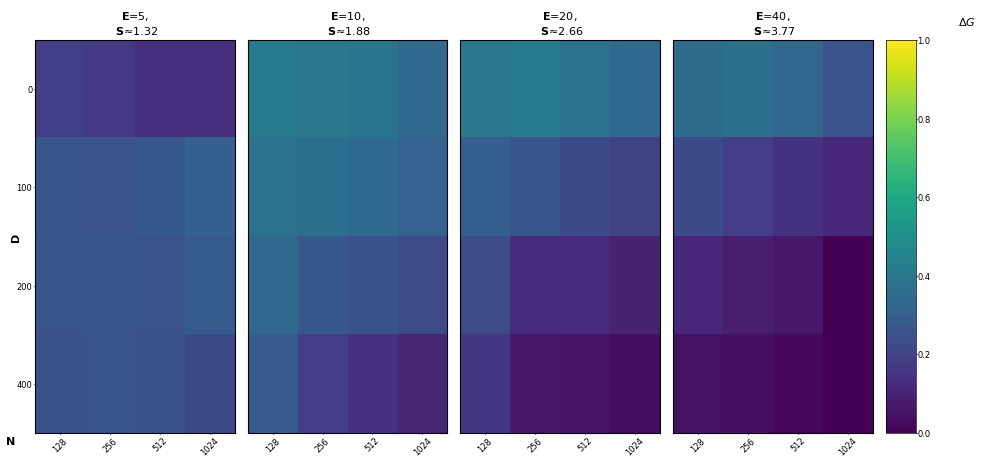

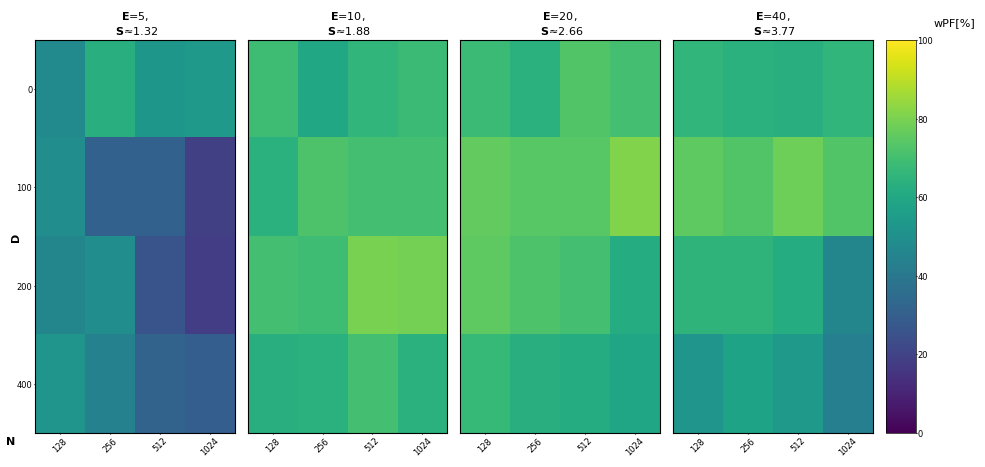

In [471]:
def generate_line(param, p, s_val):
    textt = r'$\mathbf{' + str(param) + r'}$=' + str(p)
    if param == "E":
        textt +=  ',\n' r' $\mathbf{S}$≈' + str(s_val)[:4]
    return textt

def plot_heatMap(gsCro,fig, df, paramlist, option, Y_label = True, cmincmax = None, ratio = 10, hspace = None, cbar= True):
    ''' find all possible values of param1 and param2 in the dataframe df
        then for each combination of param1 and param2, make a scatter plot along the other two parameters
        and color the points according to param_for_color
    '''
    param1, param2, param3, param4 = paramlist
    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param3_values = df[param3].unique() 
    param4_values = df[param4].unique()
    len_vals = [len(param1_values), len(param2_values), len(param3_values), len(param4_values)]

    lex = len(param1_values.tolist())
    ley = len(param2_values.tolist()) #we will add 1 for the colorbar
    print(lex, ley)
    cm = 1/2.54
    param_combinations = list(product(param1_values, param2_values))
    outer = gridspec.GridSpecFromSubplotSpec(1+1*cbar,1, height_ratios=[1] +cbar*[ratio], subplot_spec=gsCro, hspace=hspace)

    gs00 = gridspec.GridSpecFromSubplotSpec(lex, ley + 1, subplot_spec=outer[cbar], width_ratios= [1]*ley + [0.15], wspace= 0.08)
    #search for the maximum and minimum of param_for_color
    param_range = range(len(param_combinations))
    axes = []
    
    

    cmap = 'viridis'
    if option == "DeltaCorr":
        cmap = 'inferno_r'
    for k in param_range:
        x,y = k//ley , k%ley
        axes.append(fig.add_subplot(gs00[x, y]))
    
    indexp1 = param_list.index(param1)
    indexp2 = param_list.index(param2)

    if cmincmax:
        cmin, cmax = cmincmax
    else:
        cmax = np.max(Ms[option])
        cmin = np.min(Ms[option])
    
    for i in range(len(param1_values)):
        for j in range(len(param2_values)):
            
            (p1, p2 )= param1_values[i], param2_values[j]
            
            ax = axes[i*lex + j]
            ax.grid(False)
            entry = [[k for k in range(len_vals[m])] for m in range(4)]
            entry[indexp2] = [j]
            s_val = np.mean(Ms["SpectralRadius"][np.ix_(*entry)][0][0])
            entry[indexp1] = [i]

            c = ax.imshow(Ms[option][np.ix_(*entry)][0][0], origin='lower', vmin=cmin, vmax=cmax, cmap=cmap, aspect='auto')
            for axis in ['top','bottom','left','right']:
                ax.spines[axis].set_linewidth(0.5)

            #ax.scatter(grouped[param3], grouped[param4], alpha = 0.7, color = plt.cm.viridis((grouped[param_for_color] - min_color) / (max_color - min_color)))
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            if param2_values.tolist().index(p2) == 0 and Y_label :
                ax.set_ylabel(param3, fontweight = 'bold', labelpad=-3, fontsize = 8)
                ax.set_yticks([0,1,2,3],param3_values, fontsize = 6)
                ax.set_xlabel(param4, fontweight = 'bold', labelpad = -15, x = -0.1, horizontalalignment='right', fontsize = 8)

            if param1_values.tolist().index(p1) == 0:
                    ax2 = ax.twiny()
                    ax2.set_xlabel(generate_line(param2, p2, s_val), fontsize = 8)
                    ax2.set_xticks([]) 
                    ax2.xaxis.set_label_position("top")
            if param1_values.tolist().index(p1) == len(param1_values)-1:
                ax.set_xticks([0,1,2,3],param4_values,rotation=45, fontsize = 6)
            ax.invert_yaxis()
            ax.tick_params(axis='both', which='major', pad=1, length = 1, labelsize = 6)



    if cbar:
        # add a common colorbar between the maximum and minimum of param_for_color
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=cmin, vmax=cmax))
        sm.set_array([])
        cax =  fig.add_subplot(gs00[0, ley])
        cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
        cbar.outline.set_linewidth(0.5)
        if option not in ["DeltaCorr", "DeltaProx", "DeltaGoal"]:
            cbar.ax.set_yticks([0.2*k for k in range(6)], [str(20*k) for k in range(6)])
        cax.set_title(equations[option], fontsize = 8, pad = 5, y = 1.02, x=3 , horizontalalignment='right')
        cax.tick_params(axis='both', which='major', labelsize=6, length = 1, pad = 0)
    else:
        cax =  fig.add_subplot(outer[0])
        cax.axis('off')
        #cax.set_title(titles[option], fontsize = 14, pad = 30)
        a =1
    return (np.max(Ms[option]), np.min(Ms[option]))

fig = plt.figure(figsize=(25, 21))
gs = gridspec.GridSpec(3, 2, figure=fig)
plot_heatMap(gs[0,0], fig, df, param_list, "DeltaGoal",cbar = True, cmincmax= (0,1))
fig = plt.figure(figsize=(25, 21))
gs = gridspec.GridSpec(3, 2, figure=fig)
plot_heatMap(gs[0,0], fig, df, param_list, "weak",cbar = True, cmincmax= (0,1))

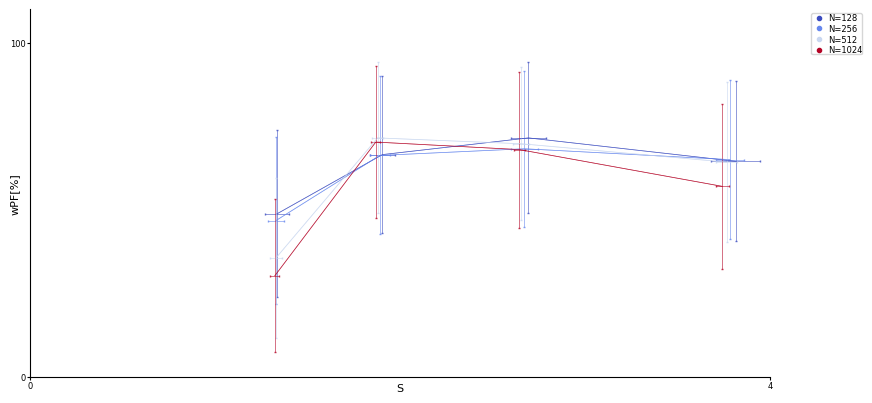

In [459]:
def make_snake(gs,option, Y_label = True, right = False, measure = 'D',cmincmax = None):
    n = n = len(df.loc[(df[measure] == df[measure].unique()[0]) & (df["spectral_radius"] == df["spectral_radius"].unique()[0])])
    k = option_list.index(option)
    ax = fig.add_subplot(gs)
    if right: # put y axis, ticks and label on the right 
        ax.yaxis.set_label_position("right")
        ax.yaxis.tick_right()

    if option in ["DeltaProx", "DeltaGoal"]:
        isDelta = True
        #ax.set_ylim(0,0.8)
    elif option in ["DeltaCorr"]:
        isDelta = True
        #ax.set_ylim(-0.8,0)
    elif option in ["SpectralRadius"]:
        isDelta = True
    else:
        isDelta = False
        ax.set_ylim(0,1.1)

    mind = df[measure].min()
    maxd = df[measure].max()
    for d in df[measure].unique():
        color = plt.cm.coolwarm((d - mind) / (maxd - mind))
        Xes = df["spectral_radius"][df[measure] == d].groupby(df["E"])
        #compute standard error of the mean for Xes supposeing Xes is a proportion
        Xerr = Xes.std() / np.sqrt(n)
        Xmean  = Xes.mean()
        Yes = df[option][df[measure] == d].groupby(df["E"])
        if option in ["DeltaProx", "DeltaGoal", "DeltaCorr"]:
            Yerr = Yes.std() / np.sqrt(n)
        else:   
            Yerr = np.sqrt(Yes.mean()*(1-Yes.mean())/len(Yes))
        Ymean  = Yes.mean()
        plt.errorbar(Xmean, Ymean, xerr=Xerr, yerr=Yerr, fmt='-', color=color, alpha=0.8, linewidth = .5, capsize = 1, capthick = 1)
        plt.plot(Xmean, Ymean, color=color, alpha=0.5, linewidth = .5,  linestyle = '-')
        plt.plot([],[], ".",color=color, label = measure+"="+str(d))
    if Y_label:
        ax.set_ylabel(equations[option], fontsize = 8, labelpad=-7)
        
    if not isDelta:
        ax.set_yticks([0,1], [0,100],  fontsize = 6)
    elif cmincmax:
        ax.set_ylim(cmincmax)
        tmin = np.ceil(cmincmax[0]*10)/10
        tmax = np.floor(cmincmax[1]*10)/10
        ax.set_yticks([tmin, tmax], [tmin, tmax], fontsize = 6)
    ax.legend(loc='upper left', borderpad=0, bbox_to_anchor=(1.05, 1), fontsize = 6, handletextpad=0,labelspacing=0.2,frameon=True)
    ax.set_xlim(0,4)
    ax.xaxis.grid(False)
    ax.tick_params(axis='both', which='major', pad=1, labelsize = 6, length = 2)
    ax.set_xticks([0,4], [0,4], fontsize = 6)
    ax.set_xlabel('S', fontsize = 8, labelpad=-5, x= 0.5)
    # take off top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig = plt.figure(figsize=(21, 21))
gs = gridspec.GridSpec(2, 2, height_ratios=(3,1), figure=fig)
#plot_heatMap(gs[0,0], fig, df, param_list, "proxy_failure")
make_snake(gs[1,0], "weak",  Y_label = True, measure = "N")




In [262]:
print(param_list)
np.mean(Ms['DeltaGoal'][:,:,0,:])


['S', 'E', 'D', 'N']


np.float64(0.31298358815579874)

## Generate all figures

1 4
(np.float64(1.0), np.float64(0.81))
1 4
(np.float64(0.56), np.float64(0.0))
1 4
(np.float64(0.81), np.float64(0.18))
1 4
(np.float64(0.77), np.float64(0.0))
1 4
(np.float64(0.5369254867169269), np.float64(0.1584840836701717))
1 4
(np.float64(0.4178530618854879), np.float64(-0.010840780595341694))
1 4
(np.float64(-0.03931310308633934), np.float64(-0.42890291181289847))


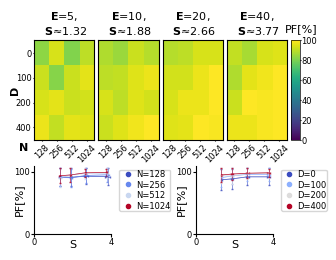

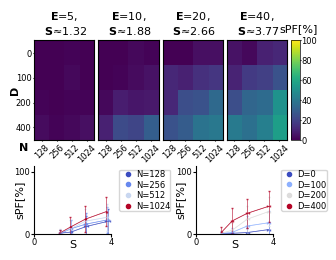

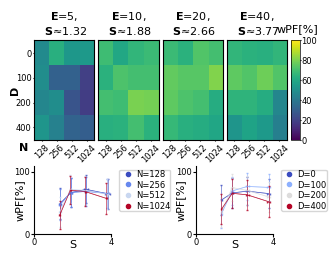

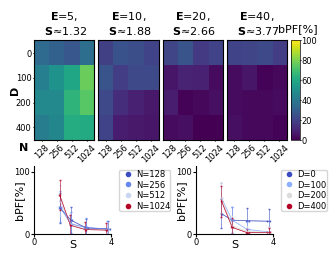

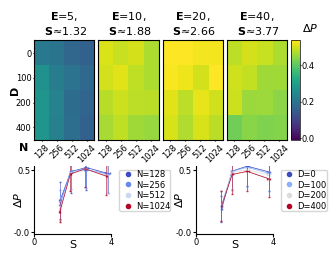

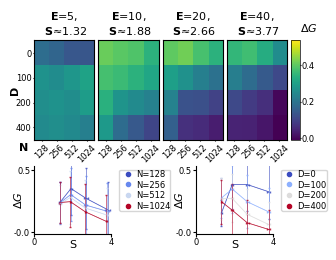

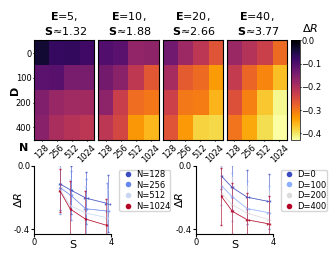

In [472]:


all_options = ['proxy_failure','strong','weak','benign','DeltaProx','DeltaGoal','DeltaCorr', "SpectralRadius"]
cbar_list = [True]*8#[False, False, False, False, True, True, True, True]
all_clist = [(0,1),(0,1), (0, 1), (0, 1), (-0.010840780595341694,0.5369254867169269), (-0.010840780595341694, 0.5369254867169269), (-0.42890291181289847,0),(0,1)]
j = 4
for k in range(len(all_options)-1): #j, j+1): #
    option = all_options[k]
    clist = all_clist[k]
    cbar = cbar_list[k]
    if cbar:
        fig = plt.figure( figsize =(8.7*cm,7.6*cm))
        gs = gridspec.GridSpec(2, 4, height_ratios=(2,1), width_ratios=(1,0.8,1,0.2), figure=fig, hspace=0.25)

        Y_label = True
        A = plot_heatMap(gs[0,0:], fig, df, param_list, option, Y_label=Y_label, cmincmax=clist, ratio = 6, hspace=0.35, cbar= cbar_list[k])
    print(A)
    make_snake(gs[1,0:1], option, Y_label=Y_label, measure= "N", cmincmax=clist)
    make_snake(gs[1,2:3], option, Y_label=Y_label, cmincmax=clist)



    #plt.savefig("figures_output/fig4.svg", format="svg", transparent=transparent)

    plt.savefig("figures_output/fig_subpart_"+ str(k) +".svg", format="svg", transparent=transparent, dpi = 400, bbox_inches = 'tight', pad_inches = 0)

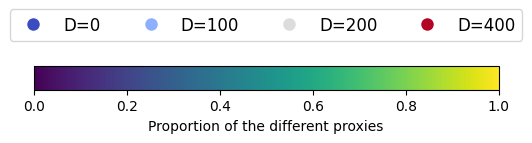

In [264]:
# creat a figure with just a colorbar for each of the 8 options, with the same colorbar as in the previous figures
fig, ax = plt.subplots(figsize=(6, 1.5))



# Create legend handles for different D values colored by coolwarm colormap
d_values = sorted(df["D"].unique())
mind = df["D"].min()
maxd = df["D"].max()

ax.axis('off')

# Create 4 legend handles colored by coolwarm based on D values
handles = []
labels = []
for d in d_values[:4]:  # Use first 4 unique D values
    color = plt.cm.coolwarm((d - mind) / (maxd - mind))
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'D={d}')
    handles.append(handle)
    labels.append(f'D={d}')

# Create legend
legend = ax.legend(handles=handles, labels=labels, loc='lower center', fontsize=12, frameon=True, ncol=4)
B = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=1))
plt.colorbar(B, ax=ax, orientation='horizontal', label='Proportion of the different proxies', fraction=1)
plt.savefig("figures_output/fig_subpart_end.png", format="png", transparent=transparent, dpi = 400, bbox_inches='tight')
plt.show()

True
1 4
(np.float64(0.77), np.float64(0.0))
False
1 4
(np.float64(0.81), np.float64(0.18))
False
1 4
(np.float64(0.56), np.float64(0.0))


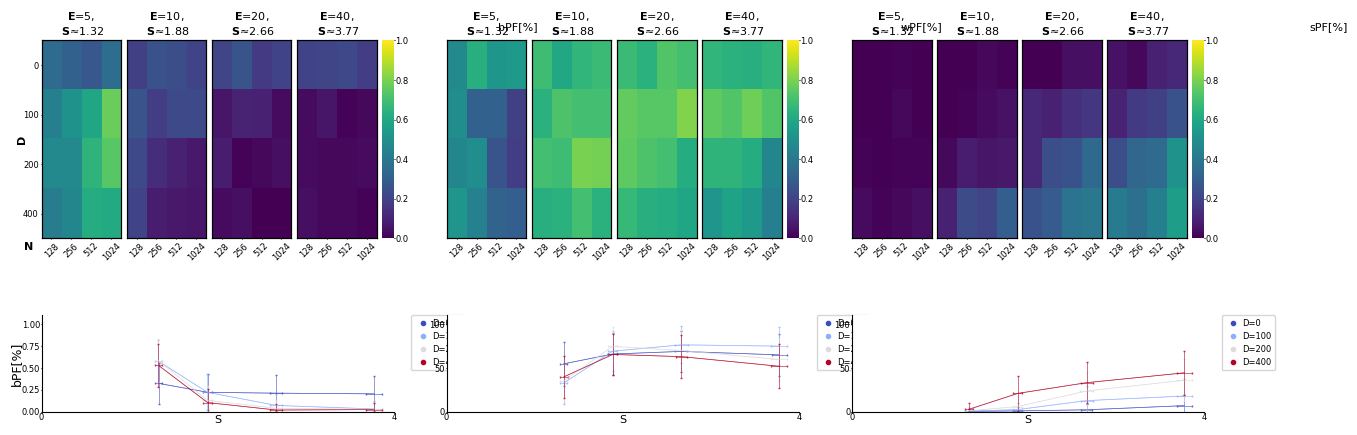

In [402]:

fig = plt.figure( figsize =(15,6))

options_fig = ['benign','weak', 'strong'] #['DeltaCorr','DeltaProx', 'DeltaGoal']
gs = gridspec.GridSpec(2, len(options_fig), height_ratios=(3,1), figure=fig, wspace=0.15, hspace=0.4)
clist = [(0,1),(0,1), (0, 1)] # [(-0.4,0),(0,0.7), (0, .7)]


for k in range(len(options_fig)):
    Y_label = k ==0
    print(Y_label)
    A = plot_heatMap(gs[0,k], fig, df, param_list, options_fig[k], Y_label=Y_label, cmincmax=clist[k], ratio = 6, hspace=0.5)
    print(A)
    make_snake(gs[1,k], options_fig[k], Y_label=Y_label)



#plt.savefig("figures_output/fig4.svg", format="svg", transparent=transparent)

plt.savefig("figures_output/fig5.png", format="png", transparent=transparent)


1 4
1 4


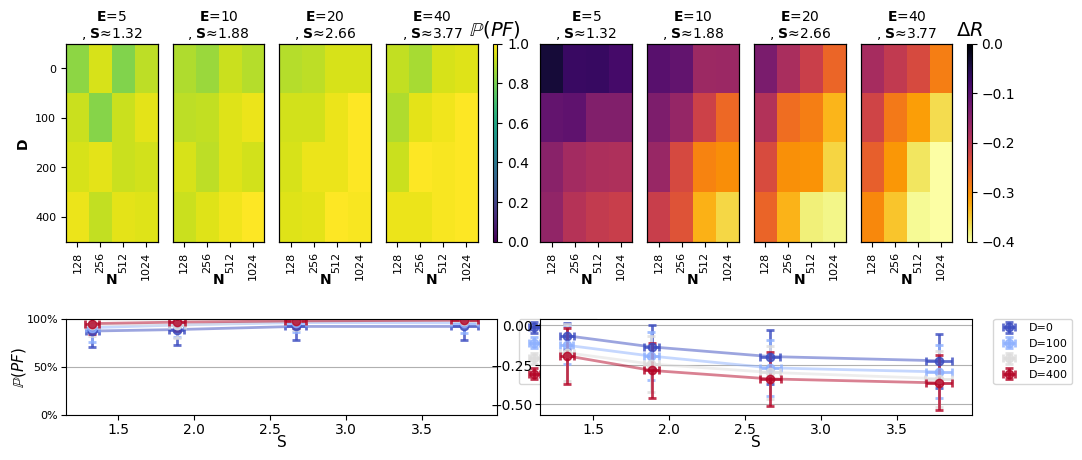

In [ ]:

fig = plt.figure( figsize =(11.69,6))
clist = [(0,1), (-0.4, 0)]
options_fig = ['proxy_failure','DeltaCorr']
if False:
    fig = plt.figure( figsize =(15,8.27))
    clist = [(-0.4,0), (0.5,1), (0, .5)]
    options_fig = ['DeltaCorr','proxy_failure','strong']

gs = gridspec.GridSpec(2, len(options_fig), height_ratios=(3,1), figure=fig, wspace=0.1, hspace=0.4)



for k in range(len(options_fig)):
    Y_label = k ==0 
    plot_heatMap(gs[0,k], fig, df, param_list, options_fig[k], Y_label=Y_label, cmincmax=clist[k], ratio = 6, hspace=0.5)
    make_snake(gs[1,k], options_fig[k], Y_label=Y_label, little_dots=False)


#plt.savefig("figures_output/fig5.svg", format="svg", transparent=transparent)
plt.savefig("figures_output/fig4.png", format="png", transparent=transparent, bbox_inches=0)


1 4
(np.float64(0.5369254867169269), np.float64(0.1584840836701717))
1 4
(np.float64(0.4178530618854879), np.float64(-0.010840780595341694))


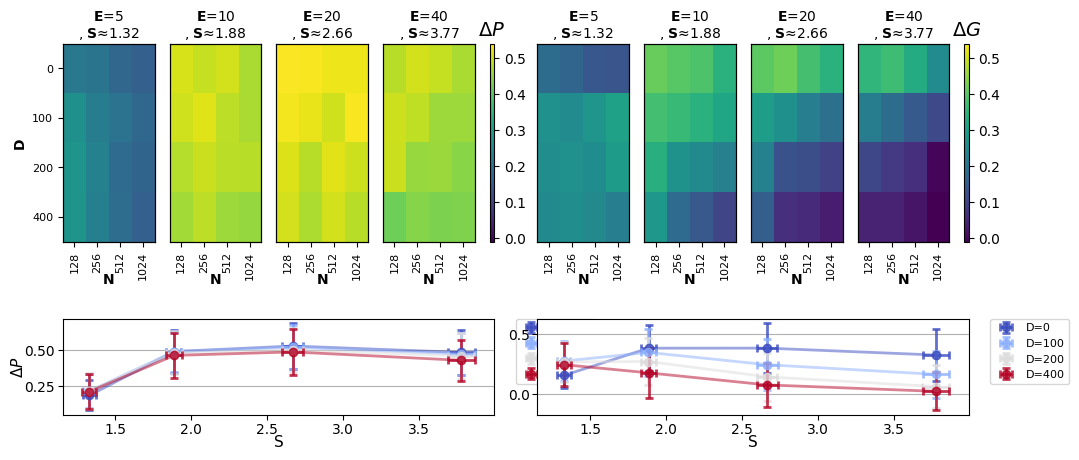

In [ ]:

fig = plt.figure( figsize =(11.69,6))
clist = [(-0.01,0.54), (-0.01,0.54)]
options_fig = ['DeltaProx','DeltaGoal']
if False:
    fig = plt.figure( figsize =(15,8.27))
    clist = [(-0.4,0), (0.5,1), (0, .5)]
    options_fig = ['DeltaCorr','proxy_failure','strong']

gs = gridspec.GridSpec(2, len(options_fig), height_ratios=(3,1), figure=fig, wspace=0.1, hspace=0.4)



for k in range(len(options_fig)):
    Y_label = k ==0 
    A = plot_heatMap(gs[0,k], fig, df, param_list, options_fig[k], Y_label=Y_label, cmincmax=clist[k], ratio = 6, hspace=0.5)
    print(A)
    make_snake(gs[1,k], options_fig[k], Y_label=Y_label, little_dots=False)


#plt.savefig("figures_output/fig5.svg", format="svg", transparent=transparent)
plt.savefig("figures_output/fig6.png", format="png", transparent=transparent, bbox_inches=0)


1 4
(np.float64(-0.03931310308633934), np.float64(-0.42890291181289847))
1 4
(np.float64(1.0), np.float64(0.81))


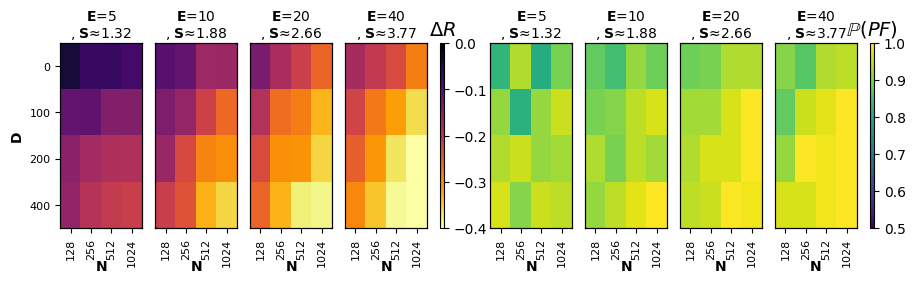

In [ ]:
transparent = True
scale = 3.5
fig = plt.figure( figsize =(scale *3, scale))

#options_fig = ['DeltaCorr','proxy_failure','strong']
options_fig = ['DeltaCorr','proxy_failure']
gs = gridspec.GridSpec(1, len(options_fig), figure=fig, wspace=0.12, hspace=0.5)

#clist = [(-0.4,0), (0.5,1), (0, .5)]
clist = [(-0.4,0),(0.5,1)]
for k in range(len(options_fig)):
    Y_label = k ==0 
    a = plot_heatMap(gs[0,k], fig, df, param_list, options_fig[k], Y_label=Y_label, cmincmax=clist[k], ratio = 6, hspace=0.5)
    print(a)


#plt.savefig("figures_output/fig5.svg", format="svg", transparent=transparent)
plt.savefig("figures_output/fig_res1.jpg", format="jpg", transparent=transparent, bbox_inches='tight', dpi = 400)

1 4


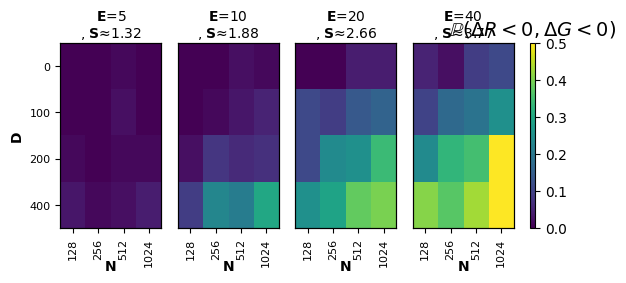

In [ ]:
scale = 3.5
fig = plt.figure( figsize =(scale *1.75, scale))

#options_fig = ['DeltaCorr','proxy_failure','strong']
options_fig = ['strong']
gs = gridspec.GridSpec(1, len(options_fig), figure=fig, wspace=0.12, hspace=0.3)

#clist = [(-0.4,0), (0.5,1), (0, .5)]
clist = [ (0, .5)]
for k in range(len(options_fig)):
    Y_label = k ==0 
    plot_heatMap(gs[0,k], fig, df, param_list, options_fig[k], Y_label=Y_label, cmincmax=clist[k], ratio = 6, hspace=0.5)


#plt.savefig("figures_output/fig5.svg", format="svg", transparent=transparent)
plt.savefig("figures_output/fig_res2.jpg", format="jpg", transparent=transparent, bbox_inches='tight', dpi = 400)

1 4
1 4


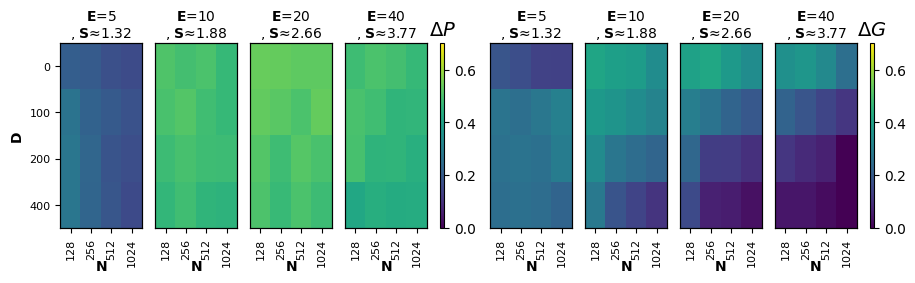

In [ ]:
scale = 3.5
fig = plt.figure( figsize =(scale *3, scale))

options_fig = ['DeltaProx', 'DeltaGoal']
gs = gridspec.GridSpec(1, len(options_fig), figure=fig, wspace=0.12, hspace=0.3)
clist = [(0,0.7), (0, .7)]


for k in range(len(options_fig)):
    Y_label = k ==0
    plot_heatMap(gs[0,k], fig, df, param_list, options_fig[k], Y_label=Y_label, cmincmax=clist[k], ratio = 6, hspace=0.5)



#plt.savefig("figures_output/fig4.svg", format="svg", transparent=transparent)

plt.savefig("figures_output/fig_res3.jpg", format="jpg", transparent=transparent, bbox_inches='tight', dpi = 400)


In [ ]:
1.15*1.75/3


0.6708333333333333